# Visualizing Tropical Storm Harold Prediction Using CorrDiff NIM

## First we want to check if our NIM is healthy and ready to be deployed 

In [2]:
import os
import requests
#check if NIM is healthy and connected 
r = requests.get("http://corrdiff-nim-service-laurahu:8000/v1/health/ready")
if r.status_code == 200:
   print("NIM is healthy!")
   print("Response:", r.text)
else:
   print("NIM is not ready!")
   print("Status:", r.status_code)
   print("Response:", r.text)

NIM is healthy!
Response: {"status":"ready"}


## Create a function that downloads and structure 

what this function does:

1. Fetch a set of select GEFS variable at a resolution 0.25-degrees on a lat-lon grid.

2. Fetch a set of regular GEFS variables at a resolution of 0.5-degrees and interpolate to 0.25 degree grid on a lat-lon grid.

3. Crop both variables to a bounded box over the United States.

4. Concatenate both sets of variables as well as an integer field that denotes the forecast lead time the input represents.

In [3]:
from datetime import datetime, timedelta
import numpy as np
import torch #interpolation 
from earth2studio.data import GEFS_FX, HRRR, GEFS_FX_721x1440 #earth2studio data source 

# corrdiff model card: https://build.nvidia.com/nvidia/corrdiff

# -----------------Inputs----------------------# 

# surface variables from high resolution source 
GEFS_SELECT_VARIABLES = [
    "u10m", #windspeed at 10m
    "v10m", #windspeed at 10m
    "t2m", #temperature at 2m
    "r2m", # relative humidity at 2m 
    "sp", 
    "msl",
    "tcwv",
]

#pressure levels vairables 
GEFS_VARIABLES = [
    "u1000",
    "u925",
    "u850",
    "u700",
    "u500",
    "u250",
    "v1000",
    "v925",
    "v850",
    "v700",
    "v500",
    "v250",
    "z1000",
    "z925",
    "z850",
    "z700",
    "z500",
    "z200",
    "t1000",
    "t925",
    "t850",
    "t700",
    "t500",
    "t100",
    "r1000",
    "r925",
    "r850",
    "r700",
    "r500",
    "r100",
]
#--------------Data source initialization-------------------#

# creates data source object for pressure levels
ds_gefs = GEFS_FX(cache=True)

# creates high resolution data source 
ds_gefs_select = GEFS_FX_721x1440(cache=True, member="gec00")


#----------------Function definition-------------------------#

def fetch_input_gefs(
    time: datetime, lead_time: timedelta, content_dtype: str = "float32"
):
    """Fetch input GEFS data and place into a single numpy array."""
    
    dtype = np.dtype(getattr(np, content_dtype))
    g = np.array(9.80665, dtype=dtype)  # standard gravity (m/s^2), converts geopotential into geopotential heights 

    # Fetch high-res select GEFS input data
    select_data = ds_gefs_select(time, lead_time, GEFS_SELECT_VARIABLES).values #721x1440, 0.25 degree
    
    # Crop to CONUS bounding box [225, 21, 300, 53]
    select_data = select_data[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert select_data.shape == (1, len(GEFS_SELECT_VARIABLES), 129, 301)

    # Fetch GEFS pressure-level input data
    pressure_data = ds_gefs(time, lead_time, GEFS_VARIABLES) #361x720, 0.5 degree 

    # Interpolate to 0.25° grid 
    pressure_data = torch.nn.functional.interpolate(
        torch.as_tensor(pressure_data.values),
        (len(GEFS_VARIABLES), 721, 1440),
        mode="nearest",
    ).numpy()

    # Crop to bounding box [225, 21, 300, 53]
    pressure_data = pressure_data[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert pressure_data.shape == (1, len(GEFS_VARIABLES), 129, 301)

    # Divide all z-levels by g to convert geopotential (m^2/s^2) -> geopotential height (m)
    z_vars = {"z1000", "z925", "z850", "z700", "z500", "z200"}
    z_indices = [i for i, v in enumerate(GEFS_VARIABLES) if v in z_vars]
    pressure_data[:, z_indices, :, :] /= g

    # Create lead time field in 3-hour increments
    lead_hour = (int(lead_time.total_seconds() // (3 * 60 * 60)) * np.ones((1, 1, 129, 301), dtype=dtype))

    # Final assembly of the output 
    input_data = np.concatenate([select_data, pressure_data, lead_hour], axis=1)[None]
    return input_data



## Specify the date and time for the input data 

In the case of the tropical storm Harold, we pick 8/22/06 with initial condition 8/22/00
Note that corrdiff can only create lead time in 3-hours increments within 24 hours

In [117]:
year = 2023
month = 8
day = 22
H = 15

time = datetime(year, month, day) # initial condition 
lead_time1 = timedelta(hours = H) # model run time, note that corrdiff only allows 24hr prediction
input_array = fetch_input_gefs(time, lead_time1)

#ensure the dimension of input is correct 
print(type(input_array), getattr(input_array, "shape", None), getattr(input_array, "dtype", None))

np.save("corrdiff_inputs.npy", input_array)


Fetching GEFS data: 100%|██████████| 7/7 [00:00<00:00, 38.90it/s]


2026-05-19 02:24:54.008 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 3716736-433150
2026-05-19 02:24:54.033 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 1753884-741687
2026-05-19 02:24:54.059 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 11303395-470525
2026-05-19 02:24:54.085 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 6117262-853850
2026-05-19 02:24:54.111 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2sp25/gec00.t00z.pgrb2s.0p25.f015 4592316-670237
2026-05-19 02:24:54.137 | DEBUG   

Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]

2026-05-19 02:24:54.194 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 9020880-143487


Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]

2026-05-19 02:24:54.209 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 5853425-265759
2026-05-19 02:24:54.223 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 6367114-124577
2026-05-19 02:24:54.235 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 6491691-241073
2026-05-19 02:24:54.248 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 7516124-140551
2026-05-19 02:24:54.260 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 5236014-117728
2026-05-19 02:24:54.272 | DEBUG    | ear

Fetching GEFS data:   0%|          | 0/30 [00:00<?, ?it/s]

2026-05-19 02:24:54.397 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 9164367-236332
2026-05-19 02:24:54.409 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 3980169-167446


Fetching GEFS data: 100%|██████████| 30/30 [00:00<00:00, 79.17it/s]


2026-05-19 02:24:54.420 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 6995715-265530
2026-05-19 02:24:54.433 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 10776097-277265
2026-05-19 02:24:54.445 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 6119184-247930
2026-05-19 02:24:54.458 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 10237233-269991
2026-05-19 02:24:54.471 | DEBUG    | earth2studio.data.gefs:fetch_array:405 - Fetching GEFS grib file: noaa-gefs-pds/gefs.20230822/00/atmos/pgrb2ap5/gec00.t00z.pgrb2a.0p50.f015 6732764-262951
2026-05-19 02:24:54.484 | DEBUG    | e

## Visualize 25-km input data around the hurricane 

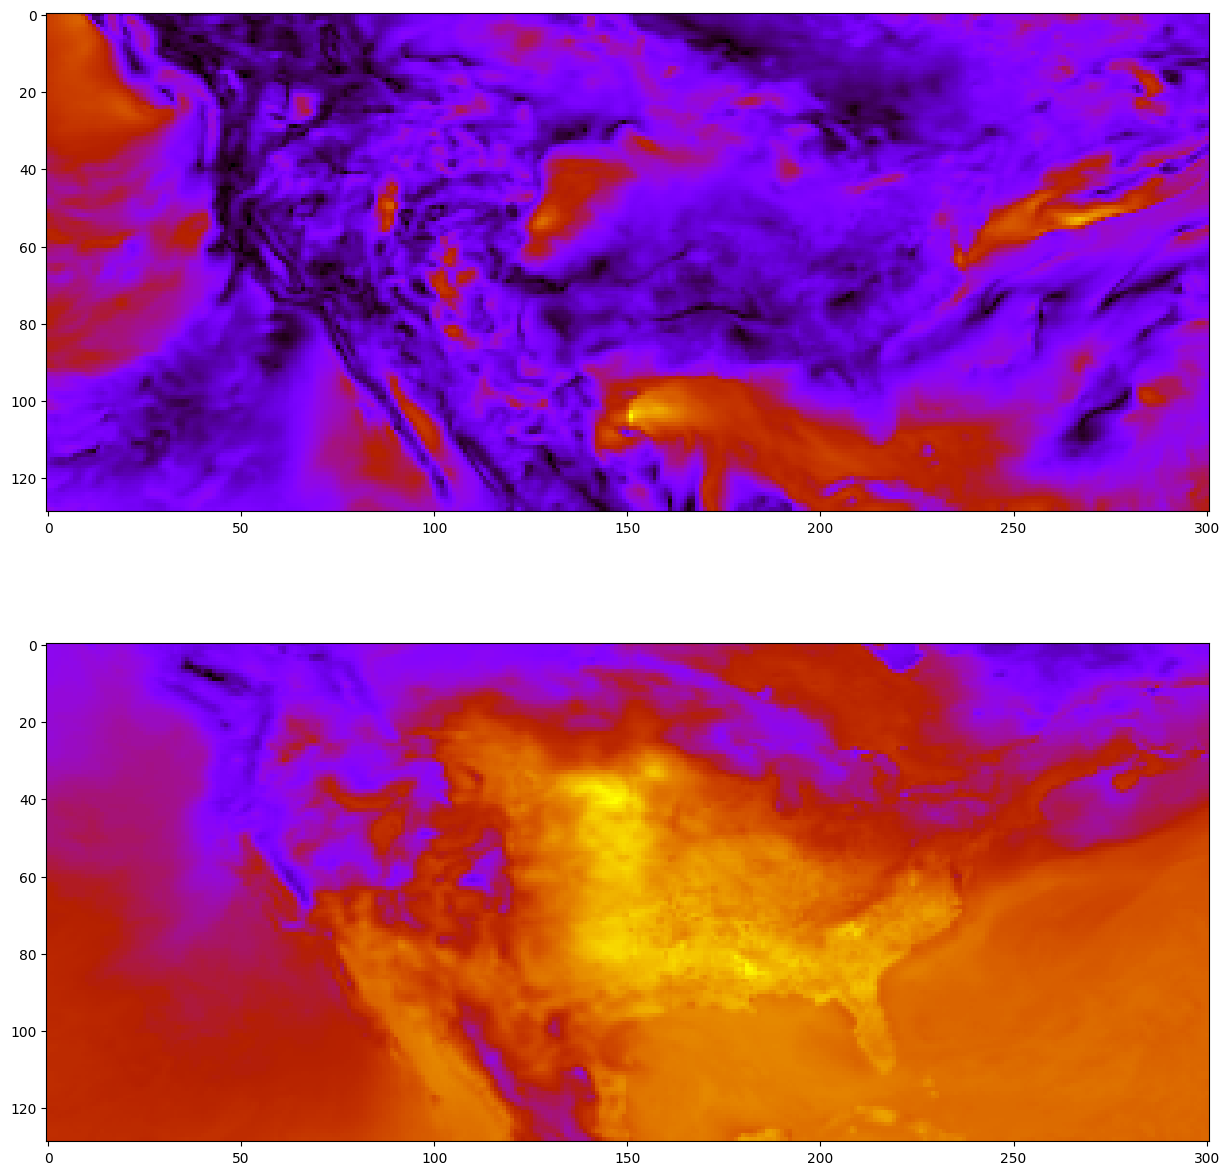

In [118]:
import matplotlib.pyplot as plt

input = np.load("corrdiff_inputs.npy")
wind_input = np.sqrt(input[0, 0, 0]**2 + input[0, 0, 1]**2)
temp_input = input[0, 0, 2]

fig, ax = plt.subplots(2,1, figsize=(15,15))
ax[0].imshow(wind_input, cmap="gnuplot")
ax[1].imshow(temp_input, cmap = "gnuplot")

plt.show()

## Requesting Inference to CorrDiff NIM

In [119]:
import io
import tarfile
from pathlib import Path
import numpy as np
import requests
import tqdm
import time 


start = time.perf_counter()
url = f"http://corrdiff-nim-service-laurahu:8000/v1/infer"
files = {
    "input_array": ("input_array", open("corrdiff_inputs.npy", "rb")),
}
data = {
    "samples": 5, # users can choose how many samples they want to generate 
    "steps": 10, # users can also choose how many steps they want the diffusion mod to take 
    "seed": 0,
}
headers = {
    "accept": "application/x-tar",
}
print("Sending post request to NIM")
r = requests.post(url, headers=headers, data=data, files=files, timeout=3000)
if r.status_code != 200:
    raise Exception(r.content)
else:
    # Dump response to file
    with open("output.tar", "wb") as tar:
        tar.write(r.content)
print("Done!")
end = time.perf_counter()
print(f"Elapsed: {end - start:.6f} seconds")

Sending post request to NIM
Done!
Elapsed: 268.190496 seconds


## Check if the raw output makes sense

In [120]:
#extract output files 
with tarfile.open("output.tar") as tar:
    for i, member in enumerate(tar.getmembers()):
        arr_file = io.BytesIO()
        arr_file.write(tar.extractfile(member).read())
        arr_file.seek(0)
        data = np.load(arr_file)

# Define a function that checks model outputs
def summarize(name, a):
    a = np.asarray(a)
    print(
        f"{name:8s}",
        "shape:", a.shape,
        "mean:", np.mean(a),
        "min/max:", np.min(a), np.max(a),
        "standard deviation:", np.std(a),
        "p1/p50/p99:", np.nanpercentile(a, [1,50,99]).tolist()
    )


var_input_name = ["u10m", "v10m","t2m", "r2m"]
var_names = ["u10m","v10m","t2m","tp","csnow","cicep","cfrzr","crain"]

print("Input stats")
for vi, name in enumerate(var_input_name):
    x = input_array[0, :, vi, :, :]  # (S,H,W)
    summarize(name, x)
    #print("----------")
print("=============================================================")
print("Output stats")
for vi, name in enumerate(var_names):
    y = data[0, :, vi, :, :]  
    summarize(name, y)
    #print("----------")



Input stats
u10m     shape: (1, 129, 301) mean: -0.96190387 min/max: -16.185143 9.504858 standard deviation: 3.3099735 p1/p50/p99: [-9.345141410827637, -0.8551415801048279, 5.89205842971803]
v10m     shape: (1, 129, 301) mean: -1.0719718 min/max: -11.942927 11.857073 standard deviation: 3.3863156 p1/p50/p99: [-8.90292739868164, -1.0329272747039795, 6.814272804260265]
t2m      shape: (1, 129, 301) mean: 295.66794 min/max: 277.11786 309.81787 standard deviation: 6.1400676 p1/p50/p99: [282.7178649902344, 294.81787109375, 307.01788330078125]
r2m      shape: (1, 129, 301) mean: 66.82761 min/max: 20.966991 99.26699 standard deviation: 15.280005 p1/p50/p99: [29.6669921875, 70.1669921875, 95.5669937133789]
Output stats
u10m     shape: (1, 1056, 1792) mean: -0.6107495 min/max: -23.369156 18.38273 standard deviation: 3.2894952 p1/p50/p99: [-9.341668424606324, -0.4304814636707306, 6.584574203491211]
v10m     shape: (1, 1056, 1792) mean: -0.97538173 min/max: -16.499557 19.755617 standard deviation

## Find the ensemble mean of all the output variables 

In [121]:
u10m_mean = []
v10m_mean = []
windspeed_mean = []
prec_mean = []

with tarfile.open("output.tar") as tar:
    for i, member in enumerate(tar.getmembers()):
        arr_file = io.BytesIO()
        arr_file.write(tar.extractfile(member).read())
        arr_file.seek(0)
        data = np.load(arr_file)

        #data_denormalized = denormalize_output(data, output_means, output_stds)
        u10 = data[0, 0, 0, :, :]
        v10 = data[0, 0, 1, :, :]
        prec = data[0, 0, 3, :, :]
        wind = np.sqrt(u10**2 + v10**2)

        u10m_mean.append(u10)
        v10m_mean.append(v10)
        windspeed_mean.append(wind)
        prec_mean.append(prec)


#ensemble_mean
u10m = np.mean(u10m_mean, axis = 0)
v10m = np.mean(v10m_mean, axis = 0)
windspeed = np.mean(windspeed_mean, axis = 0)
precp = np.mean(prec_mean, axis = 0)
summarize('windspeed sample', windspeed)
summarize('u10m sample', u10m)
summarize('v10m sample', v10m)
summarize('precipitation', precp)



windspeed sample shape: (1056, 1792) mean: 4.279747 min/max: 0.33158273 18.464169 standard deviation: 2.3061361 p1/p50/p99: [1.069941600561142, 3.7337348461151123, 10.85328077316284]
u10m sample shape: (1056, 1792) mean: -0.66360354 min/max: -17.72649 14.500757 standard deviation: 3.021367 p1/p50/p99: [-8.86041127204895, -0.40291762351989746, 5.649473180770874]
v10m sample shape: (1056, 1792) mean: -1.0026473 min/max: -12.202395 13.953577 standard deviation: 3.3005953 p1/p50/p99: [-9.100857248306275, -0.8142309784889221, 6.750058255195618]
precipitation shape: (1056, 1792) mean: 0.10162158 min/max: -0.14113593 31.430817 standard deviation: 0.6800695 p1/p50/p99: [-0.0218193219602108, 0.008257050067186356, 2.2139613556861875]


# Visualization of output variables 

## Winspeed

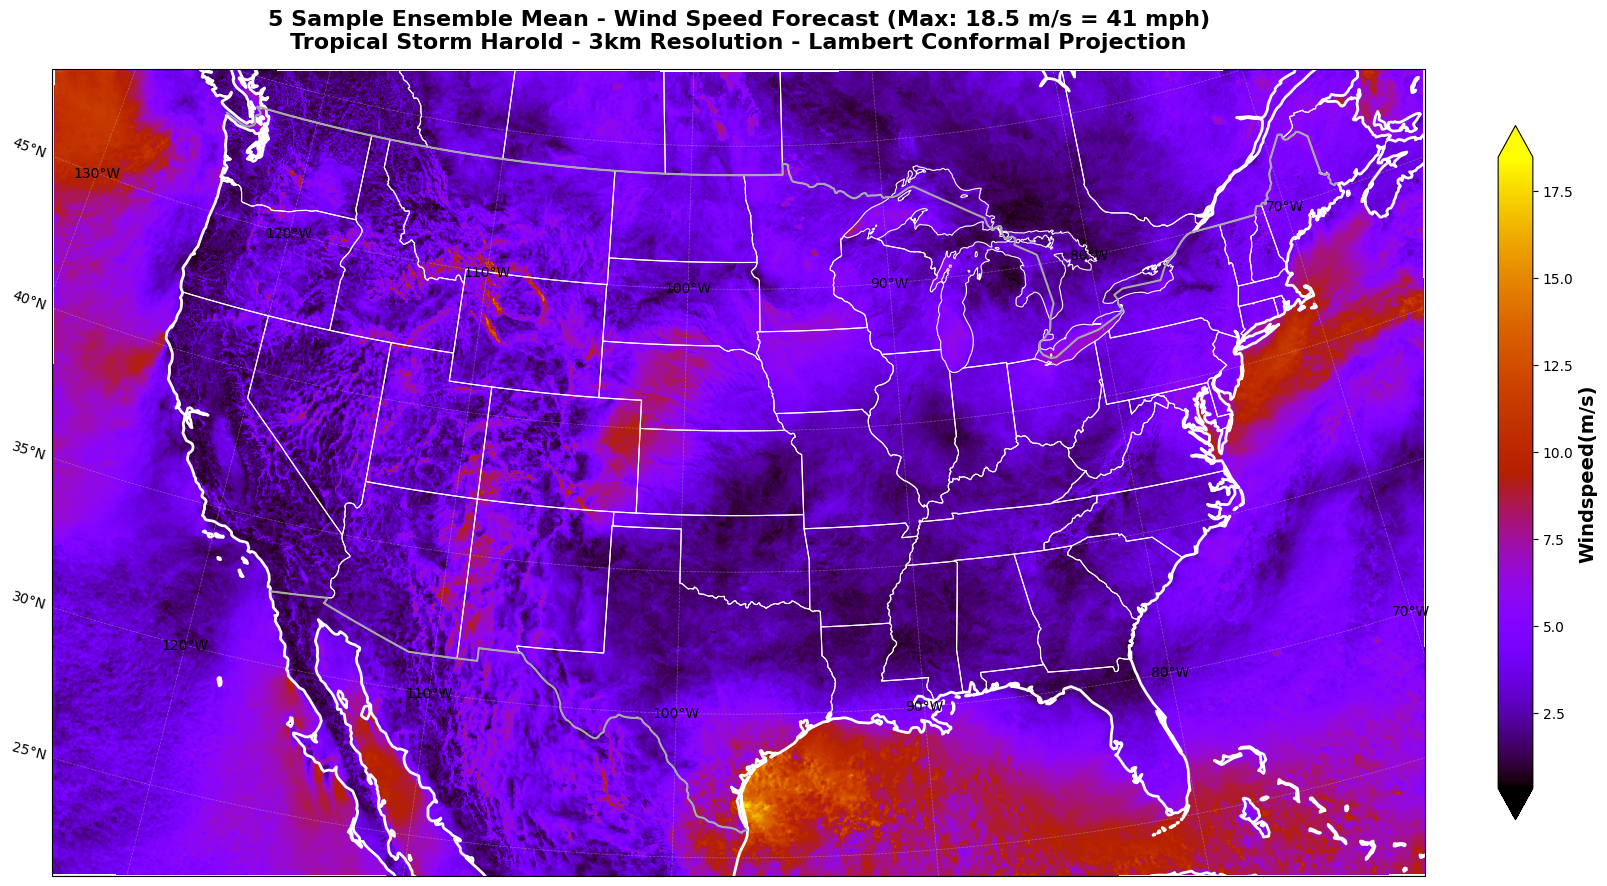

In [122]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter, percentile_filter
import matplotlib.colors as mcolors


# load the lat and lon coordinates 
lats = np.load("corrdiff_output_lat.npy")
lons = np.load("corrdiff_output_lon.npy")
lons = lons - 360

# Set up Lambert Conformal projection
projection1 = ccrs.LambertConformal(
    central_longitude=np.median(lons),
    central_latitude=np.median(lats),
    standard_parallels=(33, 45)
)


fig = plt.figure(figsize=(16, 10), layout = 'constrained')
ax = fig.add_subplot(1, 1, 1, projection=projection1)
        
#create colormap 
cmap = mpl.cm.gnuplot
bounds = np.linspace(20, 30, 11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

c = ax.pcolormesh(
        lons, lats, 
        windspeed, 
        transform=ccrs.PlateCarree(),
        cmap= 'gnuplot',
        #norm = norm
        )
        
# Add geographic features
ax.coastlines(linewidth=2, color='white')
ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='white')
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='darkgray')
#ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor='lightblue')
ax.add_feature(cfeature.OCEAN, alpha=0.2, facecolor='lightblue')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Title with statistics
max_wind = windspeed.max()
ax.set_title(
    f"5 Sample Ensemble Mean - Wind Speed Forecast (Max: {max_wind:.1f} m/s = {max_wind*2.237:.0f} mph)\n"
    f"Tropical Storm Harold - 3km Resolution - Lambert Conformal Projection",
    fontsize=16, fontweight='bold', pad=15
)

# Colorbar
cbar = plt.colorbar(c, ax=ax, shrink=0.7, pad=0.05, extend = 'both')
cbar.set_label('Windspeed(m/s)', fontsize=14, fontweight='bold')

plt.show()


## Precipitation

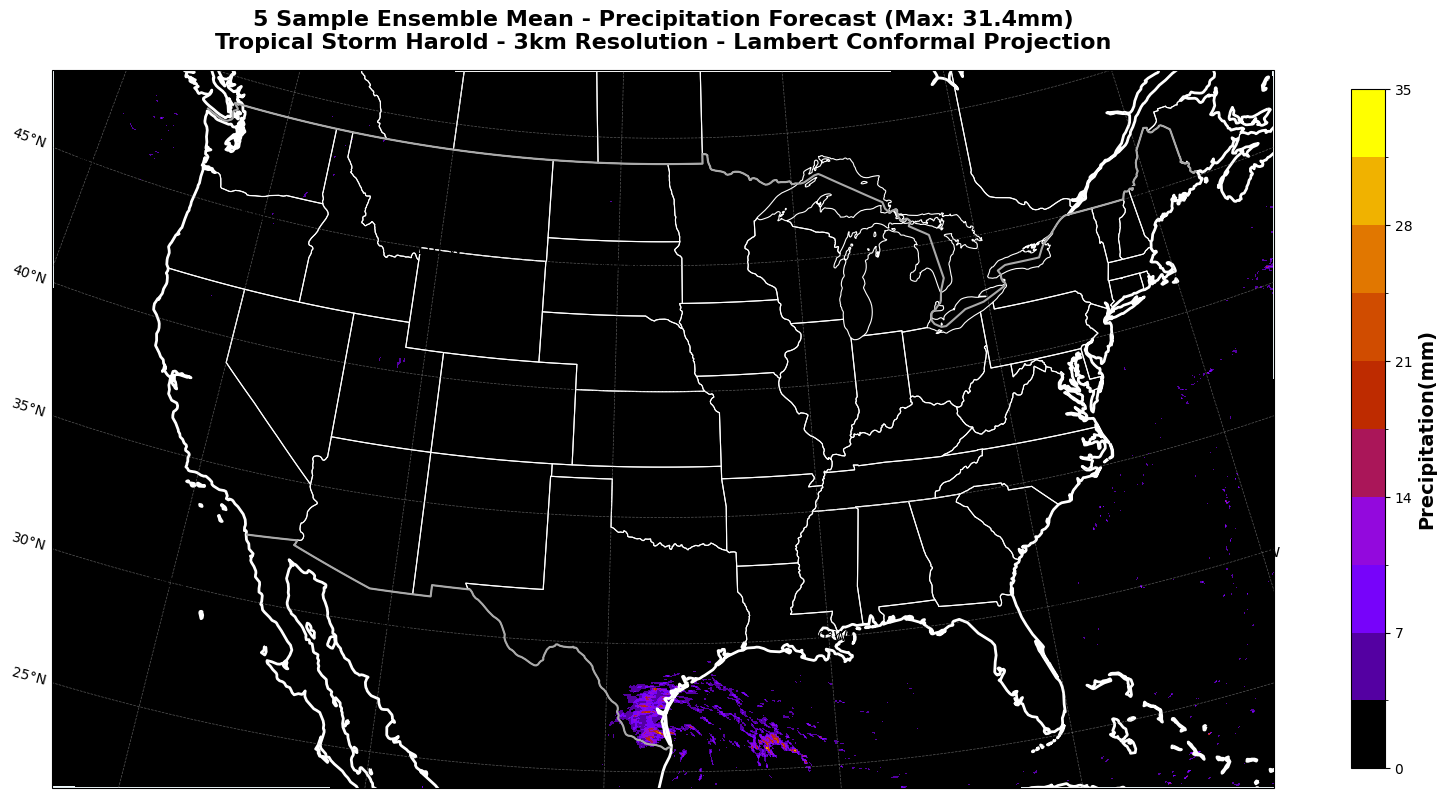

In [123]:

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=projection1)
        
cmap = mpl.cm.gnuplot
bounds = np.linspace(0, 35, 11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

c = ax.pcolormesh(
        lons, lats, 
        precp, 
        transform=ccrs.PlateCarree(),
        cmap = cmap,
        norm = norm)
        
        # Add geographic features
ax.coastlines(linewidth=2, color='white')
ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='white')
ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='darkgray')
#ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor='lightblue')
ax.add_feature(cfeature.OCEAN, alpha=0.2, facecolor='lightblue')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Title with statistics
precp_max = precp.max()
ax.set_title(
    f"5 Sample Ensemble Mean - Precipitation Forecast (Max: {precp_max:.1f}mm)\n"
    f"Tropical Storm Harold - 3km Resolution - Lambert Conformal Projection",
    fontsize=16, fontweight='bold', pad=15
)

# Colorbar
cbar = plt.colorbar(c, ax=ax, shrink=0.7, pad=0.05)
cbar.set_label('Precipitation(mm)', fontsize=14, fontweight='bold')
#plt.savefig('HurrHele_CONUS_Precp_9_26_15.png', dpi = 300)

plt.tight_layout()
plt.show()


## Create a mask on the storm region 

In [124]:
pc = ccrs.PlateCarree()

# Convert lons from 0-360° to -180 to 180°
lons = np.where(lons > 180, lons - 360, lons)

# Now use negative longitudes for Florida
la_lon = [-100.0, -90.0] 
la_lat = [25.0, 30.0]

#la_lon = [-85.5, -84.0] 
#la_lat = [26.0, 27.0]

central_lon = (la_lon[0] + la_lon[1]) / 2  # -85.0
central_lat = (la_lat[0] + la_lat[1]) / 2  # 28.5

projection2 = ccrs.LambertConformal(
    central_longitude=central_lon,
    central_latitude=central_lat,
    standard_parallels=(30, 60)  # or adjust for your region
)

# Create mask
mask = ((lons >= la_lon[0]) & (lons <= la_lon[1]) &
        (lats >= la_lat[0]) & (lats <= la_lat[1]))

# Apply mask
wind_10_masked = np.where(mask, windspeed, np.nan)


In [125]:

# These colors approximately match the GPCP scale in your image
gpcp_colors = [
    '#dfc2a5', # 0-1 (Tan)
    '#7ec9d0', # 1-2 (Light Blue)
    '#5eb35e', # 2-3 (Green)
    '#99cc33', # 3-4 (Light Green)
    '#f2f22e', # 4-5 (Yellow)
    '#e6e600', # 5-6 (Darker Yellow)
    '#ff9999', # 6-7 (Pink/Salmon)
    '#ff4d4d', # 7-8 (Red)
    '#cc0000', # 8-9 (Deep Red)
    '#993366', # 9-10 (Purple)
    '#1a1a1a'  # >10 (Near Black)
]
levels = np.linspace(0, 25, 21)
# Create the colormap object
continuous_cmap = mcolors.LinearSegmentedColormap.from_list("gpcp_cont", gpcp_colors)
custom_cmap = mcolors.ListedColormap(continuous_cmap(np.linspace(0, 1, len(levels)-1)))

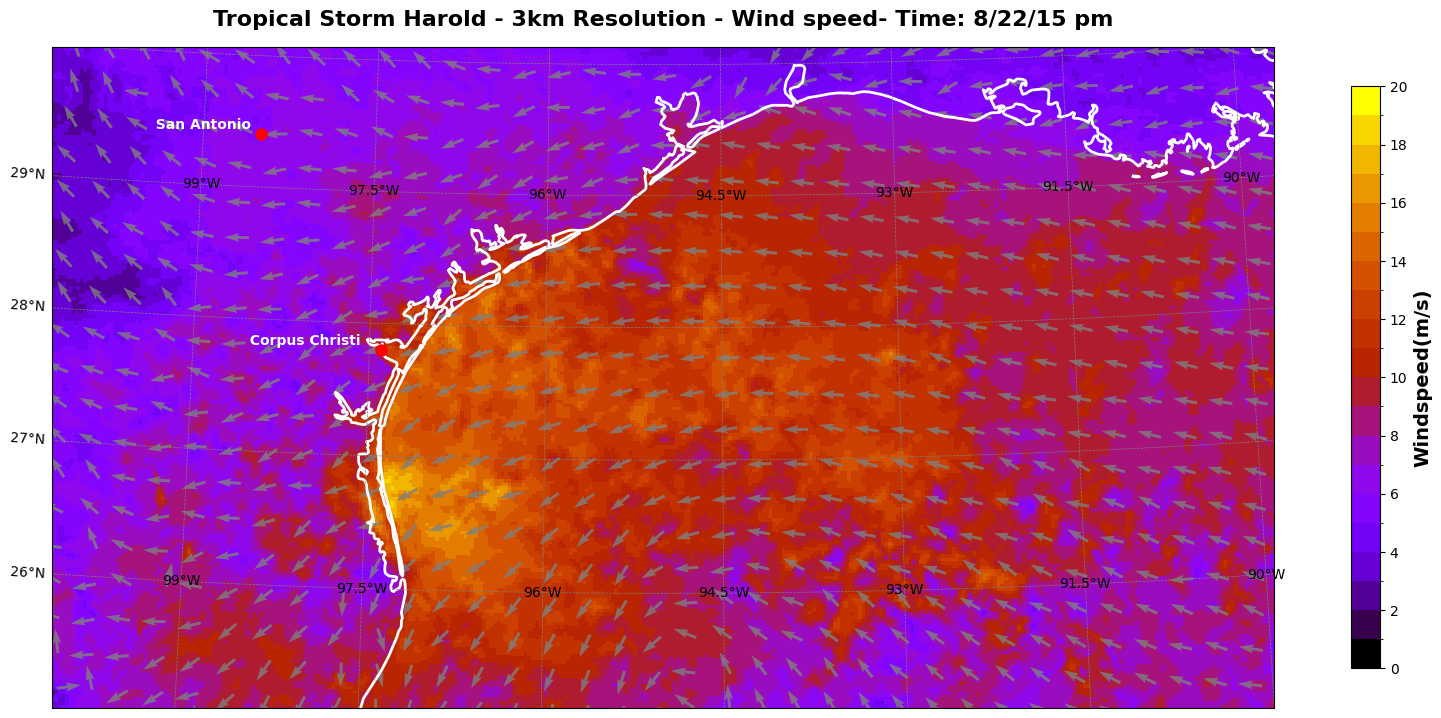

In [130]:
# Plot

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=projection2)

levels = np.linspace(0, 20, 21)


norm = mcolors.BoundaryNorm(levels, ncolors = 256)
c = ax.pcolormesh(
    lons, lats,
    windspeed,
    transform=pc,
    norm=norm,
    cmap= 'gnuplot'
)

ax.set_extent([la_lon[0], la_lon[1], la_lat[0], la_lat[1]], crs=pc)
ax.quiver(
    lons[::skip, ::skip], 
    lats[::skip, ::skip],
    u_norm,
    v_norm,
    transform=pc,
    color='gray', # Arrow color  
    alpha = 0.8,
    scale = 50)

# Add quiver plot 
#quiver

# Add geographic features
ax.coastlines(linewidth=2, color='white')

ax.plot(-97.4, 27.8, 'ro', markersize=8, transform=pc, zorder=5)
ax.text(-98.6, 27.8, '  Corpus Christi', color='white', fontsize=10, 
        fontweight='bold', transform=pc, zorder=5)

ax.plot(-98.5, 29.4, 'ro', markersize=8, transform=pc, zorder=5)
ax.text(-99.5, 29.4, '  San Antonio', color='white', fontsize=10, 
        fontweight='bold', transform=pc, zorder=5)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', color = 'gray')
gl.top_labels = False
gl.right_labels = False

# Automate AM and PM
if H < 12:
    switch = "am"
else:
    switch = "pm"

ax.set_title(
    f"Tropical Storm Harold - 3km Resolution - Wind speed"
    f"- Time: {month}/{day}/{H} {switch}",
    fontsize=16, fontweight='bold', pad=15
)


# Colorbar
cbar = plt.colorbar(c, ax=ax, ticks = levels[::2], shrink = 0.6)
cbar.set_label('Windspeed(m/s)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Harold_{day}_{H}_wind.png", dpi = 300)
plt.show()





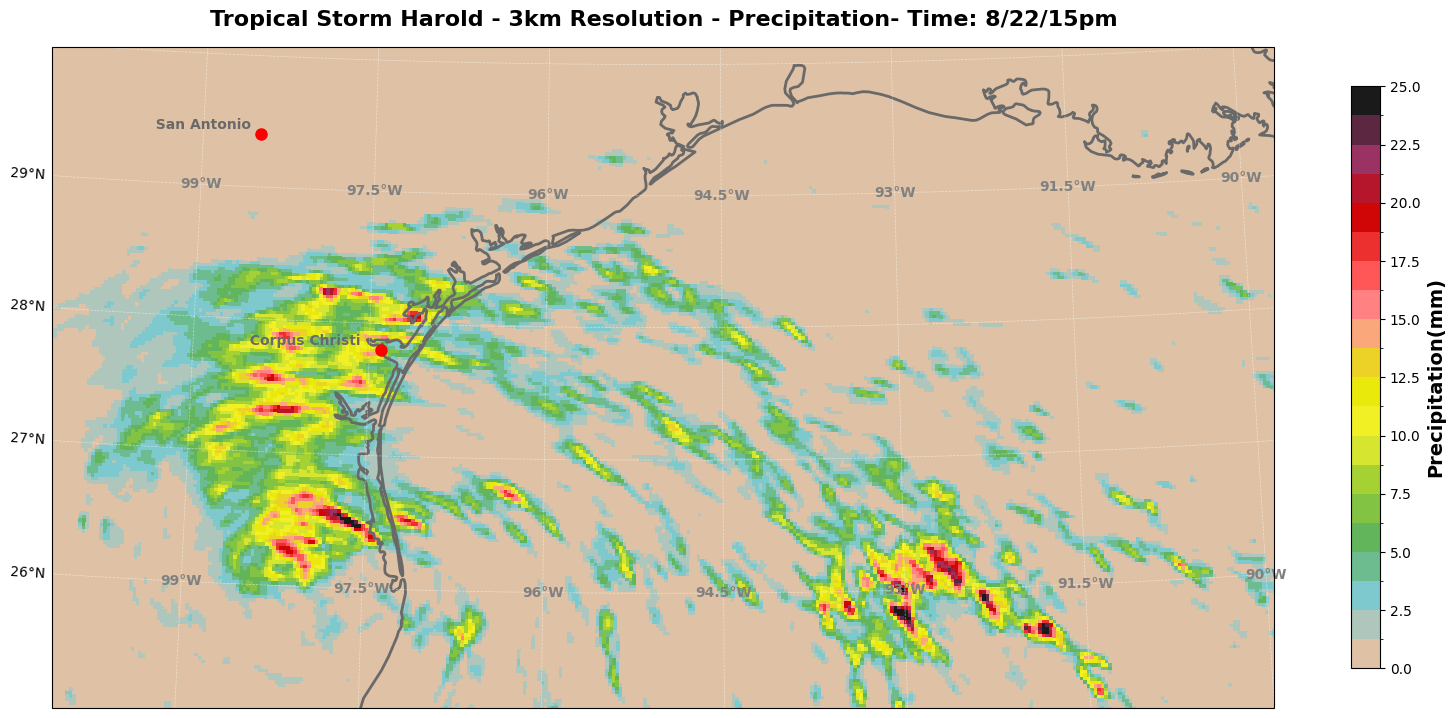

In [127]:

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=projection2)

# Plot wind speed (color background)

levels = np.linspace(0, 25, 21)
norm = mcolors.BoundaryNorm(levels, ncolors=custom_cmap.N)
c = ax.pcolormesh(
    lons, lats,
    precp,
    transform=pc,
    norm = norm,
    cmap= custom_cmap
)

# Set the view extent
ax.set_extent([la_lon[0], la_lon[1], la_lat[0], la_lat[1]], crs=pc)



# Add geographic features
ax.coastlines(linewidth=2, color='dimgray')

ax.plot(-97.4, 27.8, 'ro', markersize=8, transform=pc, zorder=5)
ax.text(-98.6, 27.8, '  Corpus Christi', color='dimgray', fontsize=10, 
        fontweight='bold', transform=pc, zorder=5)

ax.plot(-98.5, 29.4, 'ro', markersize=8, transform=pc, zorder=5)
ax.text(-99.5, 29.4, '  San Antonio', color='dimgray', fontsize=10, 
        fontweight='bold', transform=pc, zorder=5)


# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--', color = 'white')
gl.xlabel_style = {'color': 'gray', 'weight': 'bold'}
gl.top_labels = False
gl.right_labels = False


ax.set_title(
    f"Tropical Storm Harold - 3km Resolution - Precipitation"
    f"- Time: {month}/{day}/{H}{switch}",
    fontsize=16, fontweight='bold', pad=15
)

# Colorbar
cbar = plt.colorbar(c, ax=ax, ticks = levels[::2], shrink = 0.6)
cbar.set_label('Precipitation(mm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Harold_{day}_{H}_precp.png", dpi = 300)
plt.show()
